**Graph I**

Our first LangGraph graph!


In [ ]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

In [ ]:
class AgentState(TypedDict):
  message: str

def greeting_node(state: AgentState) -> AgentState:
  """Simple node that adds a greeting message to state"""
  state['message'] = "Hey " + state['message'] + ", How are ya doing?"

  return state


In [ ]:
graph = StateGraph(AgentState)

graph.add_node("greeter", greeting_node)
graph.set_entry_point("greeter")
graph.set_finish_point("greeter")

app = graph.compile()

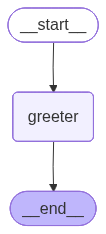

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
result = app.invoke({"message": "yogi"})
result['message']

'Hey yogi, How are ya doing?'

**Exercise**

In [ ]:
from typing import Dict , TypedDict
from langgraph.graph import StateGraph

In [ ]:
class AgentState(TypedDict):
  name : str

def compliment_node(state: AgentState) ->AgentState:

  state['name'] = state['name'] + " you're doing an amazing job learning langGraph"

  return state

In [ ]:
graph = StateGraph(AgentState)

graph.add_node("compliment", compliment_node)
graph.set_entry_point("compliment")
graph.set_finish_point("compliment")

app = graph.compile()

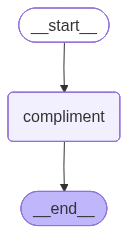

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
result = app.invoke({"name":"yogi"})
result['name']

"yogi you're doing an amazing job learning langGraph"

Excercise - 2


In [ ]:
from typing import Dict, TypedDict , List
from langgraph.graph import StateGraph
import math

class AgentState(TypedDict):
  values: List[int]
  name: str
  operation: str
  result : str


def process_value(state: AgentState) -> AgentState:
  """ This graph contains multiple values"""

  if state["operation"] == "+":
    state["result"] = f"Hi {state['name']}, your answer is: {sum(state['values'])}"

  elif state["operation"] == "*":
    state["result"] = f"HI there {state["name"]}, your answer is {math.prod(state["values"])}"

  else:
    state["result"] = "Invalid"

  return state


graph = StateGraph(AgentState)
graph.add_node("process", process_value)
graph.set_entry_point("process")
graph.set_finish_point("process")

app = graph.compile()



In [ ]:
answer = app.invoke({ "values": [1,2,3,4,5,6], "name":"yogi",  "operation":"*" })

print(answer["result"])

HI there yogi, your answer is 720


Excercise - 3

In [ ]:
from typing import Dict, TypedDict , List
from langgraph.graph import StateGraph

class AgentState(TypedDict):
  name : str
  age : int
  skills : List[str]
  result : str

def first_node(state: AgentState) -> AgentState:
  """This is first node of  graph"""

  state['result'] = f"Hey {state['name']}, Welcome to this system "
  return state

def second_node(state:AgentState) -> AgentState:
  """This is second node of graph"""

  state['result'] = state['result'] + f"You are {state['age']} old "
  return state

def third_node(state: AgentState) -> AgentState:
  """This is third node in graph"""

  state['result'] = state['result'] + f"and you have skills in : {state['skills']}"
  return state


graph = StateGraph(AgentState)

graph.add_node("Greeting_node", first_node)
graph.add_node("Age_node", second_node)
graph.add_node("Skill_node", third_node)

graph.set_entry_point("Greeting_node")
graph.add_edge("Greeting_node", "Age_node")
graph.add_edge("Age_node", "Skill_node")
graph.set_finish_point("Skill_node")

app = graph.compile()

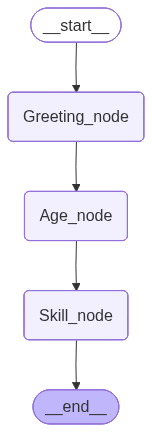

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
answer = app.invoke({"name":"Yogesh","age":"20","skills":["python", "Langchain", "langgraph"]})
print(answer["result"])

Hey Yogesh, Welcome to this system You are 20 old and you have skills in : ['python', 'Langchain', 'langgraph']


Exervise - 4

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
  number1 : int
  operation1 : str
  number2: int
  final_number1: int
  number3: int
  operation2: str
  number4: int
  final_number2: int

def adder(state: AgentState) -> AgentState:
  "this node adds 2 number"

  state['final_number1'] = state['number1'] + state['number2']
  return state

def subtracter(state: AgentState) -> AgentState:
  "this node subs 2 numbers"

  state['final_number1'] = state['number1'] - state['number2']
  return state

def decide_next_node(state: AgentState) -> AgentState:
  "this node decides next node"

  if state['operation1'] == "+":
    return "Addition_operation"

  elif state['operation1'] =="-":
    return "Subraction_operation"


def adder2(state: AgentState) -> AgentState:
  "this node adds 2 number"

  state['final_number2'] = state['number3'] + state['number4']
  return state

def subtracter2(state: AgentState) -> AgentState:
  "this node subs 2 numbers"

  state['final_number2'] = state['number3'] - state['number4']
  return state

def decide_next_node2(state: AgentState) -> AgentState:
  "this node decides next node"

  if state['operation2'] == "+":
    return "Addition_operation2"

  elif state['operation2'] =="-":
    return "Subraction_operation2"



In [ ]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("sub_node", subtracter)
graph.add_node("router", lambda state:state)


graph.add_node("add_node2", adder2)
graph.add_node("sub_node2", subtracter2)
graph.add_node("router2", lambda state:state)

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "Addition_operation": "add_node",
        "Subraction_operation": "sub_node"
    }
)

graph.add_edge("add_node", "router2")
graph.add_edge("sub_node", "router2")


graph.add_conditional_edges(
    "router2",
    decide_next_node2,
    {
        "Addition_operation2": "add_node2",
        "Subraction_operation2": "sub_node2"
    }
)

graph.add_edge("add_node2", END)
graph.add_edge("sub_node2", END)

app = graph.compile()


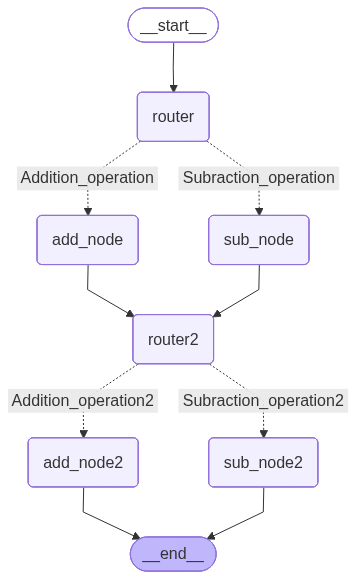

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
initial_state = AgentState(number1 = 10, operation1="-", number2 = 5, number3 = 7, number4=2, operation2="+", finalNumber1= 0, finalNumber2 = 0)
print(app.invoke(initial_state))

{'number1': 10, 'operation1': '-', 'number2': 5, 'final_number1': 5, 'number3': 7, 'operation2': '+', 'number4': 2, 'final_number2': 9}


In [17]:
from langgraph.graph import StateGraph, END
import random
from typing import Dict, List, TypedDict

class AgentState(TypedDict):
  name : int
  random : List
  counter: int

def greet_node(state : AgentState) -> AgentState:
  "this node is to greet the user"

  state['name'] =  f"Hi there, {state['name']}! "
  state['counter'] = 0

  return state

def random_node(state:  AgentState) -> AgentState:
  "This node is to generate random numbers"

  state['random'].append(random.randint(0, 10))
  state['counter'] += 1

  return state

def should_continue(state: AgentState) -> AgentState:
  "this is to continue the loop"

  if state['counter'] < 5:
    print("ENTERING LOOPING", state['counter'])
    return "loop"
  else:
    return "Exit"


In [18]:
graph  =  StateGraph(AgentState)

graph.add_node("greet", greet_node)
graph.add_node("random", random_node)
graph.add_edge("greet", "random")

graph.add_conditional_edges(
    "random",
    should_continue,
    {
        "loop": "random",
        "Exit": END
    }
)

graph.set_entry_point("greet")

app = graph.compile()

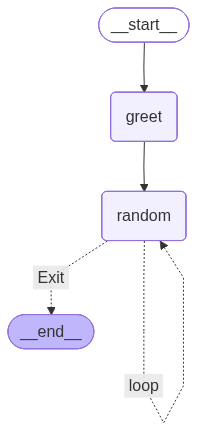

In [10]:
graph.compile()

In [19]:
app.invoke({"name":"yogesh", "random":[], "counter":2})

ENTERING LOOPING 1
ENTERING LOOPING 2
ENTERING LOOPING 3
ENTERING LOOPING 4


{'name': 'Hi there, yogesh! ', 'random': [0, 9, 1, 1, 2], 'counter': 5}